# 07 · Part 2: the quarterly refresh pipeline

A new file arrives every quarter. This notebook is the repeatable path for handling it, so a refresh
needs no code changes.

The pipeline answers **two different questions**, and which one you want depends on why you are
looking:

| Mode | Question | Needs the history? |
|---|---|---|
| **`standalone`** | What does this new quarter say on its own? | No |
| **`append`** | How does the whole series look now that this quarter is in it? | Yes |
| **`both`** | Both, in that order *(default)* | Yes |

The ordering is deliberate: **standalone runs first**, so a new file can be inspected *before* any
decision to admit it to the historical series. If it looks wrong, nothing has been written.

## Setup

In [ ]:
import sys
from pathlib import Path

# Walk up until src/csbc.py is found, so the notebook runs whether Jupyter was started
# in the project root or in src/. Nothing here depends on an absolute path.
_here = Path.cwd().resolve()
_root = next(p for p in (_here, *_here.parents) if (p / "src" / "csbc.py").exists())
sys.path.insert(0, str(_root / "src"))

import pandas as pd
import matplotlib.pyplot as plt

import csbc

csbc.ensure_dirs()
csbc.apply_chart_theme()

pd.set_option("display.width", 120)
pd.set_option("display.max_colwidth", 48)

print(f"project: {csbc.ROOT.name}/")
print(f"raw data: {len(sorted(csbc.RAW_DIR.glob('*.csv')))} quarterly CSVs in data/raw")

project: business_data_lab_assignment/
raw data: 4 quarterly CSVs in data/raw


## The ingest contract

Five conditions must hold before any data is appended. Each **raises**, because each means the
incoming file is structurally different from what the analysis assumes:

1. **Schema**: all six columns present.
2. **Quarter integrity**: exactly one valid `Q# YYYY` per incoming file.
3. **Value range**: percentages numeric and within 0–100.
4. **Key uniqueness**: no duplicate `GEO × characteristic × metric × direction × quarter`.
5. **Known categories only**: after the documented aliases are applied, an unknown label is drift to
   review, not something to absorb silently.

Two more guards apply at append time: a **quarter already present** is refused, and the **combined
union is re-validated** after concatenation, because a duplicate key spanning two files is invisible
when each file is checked alone.

All of this lives in `csbc.py`, so the notebook, the tests and the CLI enforce the same contract.

## A live demonstration

There is no Q3 2024 file to hand, so the demo **holds Q2 2024 back**: it builds a history from the
first three quarters, then ingests Q2 2024 as though it had just arrived.

In [ ]:
import shutil
import tempfile

# The demo writes to a temporary folder so the project's own combined dataset is not
# disturbed by running this notebook.
demo_dir = Path(tempfile.mkdtemp(prefix="csbc_demo_"))
demo_history = demo_dir / "combined_csbc.csv"

# No Q3 2024 file exists, so Q2 2024 is held back and treated as "the new arrival".
# This exercises the real path, including the two label changes Q2 2024 introduced.
history_files = [p for p in sorted(csbc.RAW_DIR.glob("*.csv")) if "Q2 2024" not in p.name]
new_quarter_file = csbc.RAW_DIR / "Data CSBC-Q2 2024.csv"

history, _, _ = csbc.combine_quarters(history_files)
history.to_csv(demo_history, index=False)

print("history built from:", [p.name for p in history_files])
print(f"  {len(history):,} rows, quarters {csbc.sort_quarters(history['Quarter'])}")
print("new file to ingest:", new_quarter_file.name)

history built from: ['Data CSBC-Q1 2024.csv', 'Data CSBC-Q3 2023.csv', 'Data CSBC-Q4 2023.csv']
  7,056 rows, quarters ['Q3 2023', 'Q4 2023', 'Q1 2024']
new file to ingest: Data CSBC-Q2 2024.csv


### Mode 1: `standalone`: what does this quarter say by itself?

No history required. This is the "should we accept this file, and what is in it?" view.

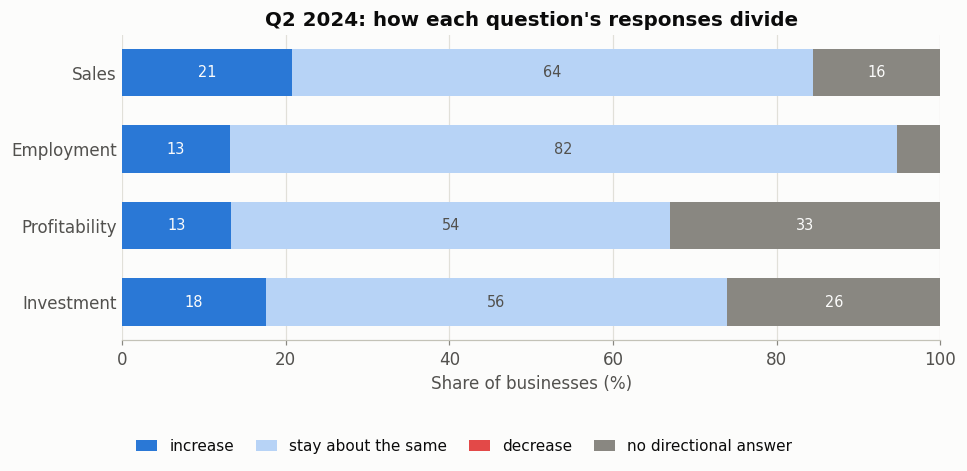

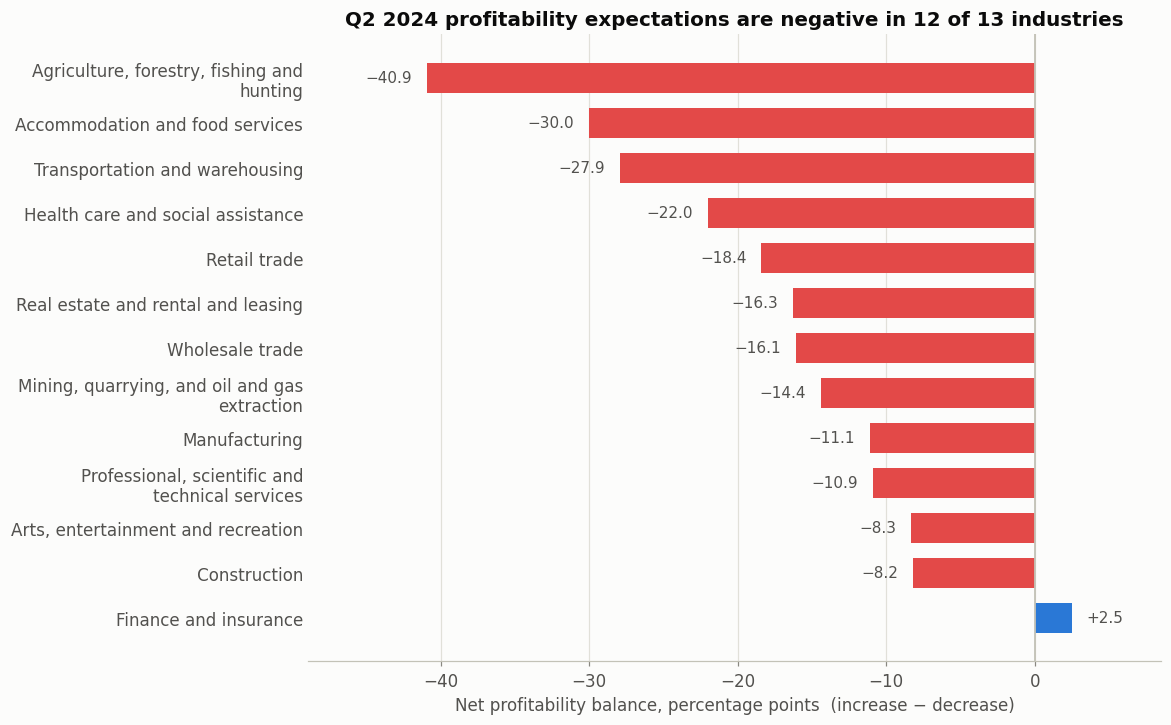


Standalone view of Q2 2024
  rows: 2,352
  missing VALUE cells: 7
  labels normalised: {'Capital Investment': 588, 'stay the same': 784}
  industries with a negative profitability balance: 12 of 13


In [3]:
standalone = csbc.analyse_single_quarter(new_quarter_file,
                                        output_dir=csbc.OUTPUT_DIR)

The composition chart doubles as a data-quality check: the grey "no directional answer" band is the
residual from notebook `01`, visible immediately for a brand-new file. The sector balance is the
stakeholder view of the quarter in isolation.

Note what the standalone mode reported without needing any prior data: 2,352 rows, the seven missing
cells, the two labels it rewrote, and 12 of 13 industries with negative margin expectations.

### Mode 2: `append`: how does the series look now?

Appends the validated quarter to the history, re-validates the union, and refreshes the trend chart
across all quarters.

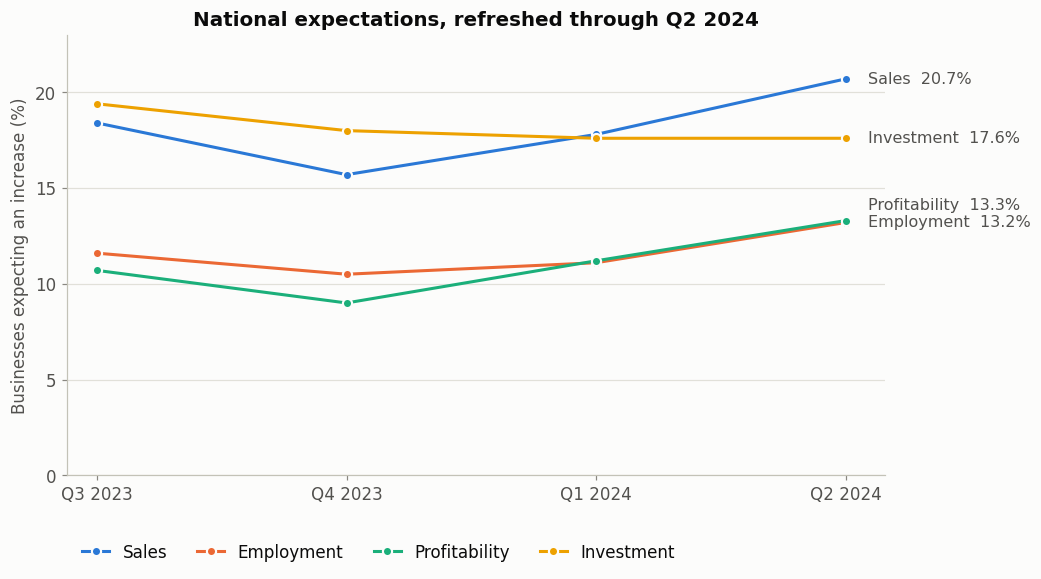


Ingested Q2 2024: 2,352 rows
  history now holds 9,408 rows across 4 quarters
  saved: combined_csbc.csv


Business_information,Sales,Employment,Profitability,Investment
Quarter,,,,
Q3 2023,18.4,11.6,10.7,19.4
Q4 2023,15.7,10.5,9.0,18.0
Q1 2024,17.8,11.1,11.2,17.6
Q2 2024,20.7,13.2,13.3,17.6


In [ ]:
appended = csbc.ingest_and_refresh(new_quarter_file, combined_file=demo_history,
                                   output_dir=csbc.OUTPUT_DIR)
appended["trend"]

The history grew from 7,056 to 9,408 rows, Q2 2024's two renamed labels were normalised on the way
in, its seven missing percentages were retained as missing, and the trend now runs across four
quarters.

## The guards, exercised

Describing failure modes is cheap. The cells below actually trigger them, each should be **blocked**.

In [ ]:
def expect_refusal(label, action):
    """Run an action that should be blocked, and report the refusal."""
    try:
        action()
    except ValueError as error:
        print(f"BLOCKED  {label}\n         {error}\n")
    else:
        print(f"NOT BLOCKED  {label} - the guard did not fire\n")


# 1. The same quarter twice - re-running must never double-count.
expect_refusal(
    "re-ingesting a quarter already in the history",
    lambda: csbc.ingest_and_refresh(new_quarter_file, combined_file=demo_history,
                                    output_dir=demo_dir),
)

# 2. A metric label nobody has mapped yet.
drifted_file = demo_dir / "drifted.csv"
drifted = csbc.read_csv(csbc.RAW_DIR / "Data CSBC-Q3 2023.csv")
drifted.loc[drifted["Business_information"] == "Investment", "Business_information"] = (
    "Capital Expenditure"
)
drifted.to_csv(drifted_file, index=False)
expect_refusal("an unrecognised Business_information label",
               lambda: csbc.load_quarter(drifted_file))

# 3. A renamed column.
renamed_file = demo_dir / "renamed.csv"
csbc.read_csv(csbc.RAW_DIR / "Data CSBC-Q3 2023.csv").rename(
    columns={"VALUE": "Value"}).to_csv(renamed_file, index=False)
expect_refusal("a renamed VALUE column", lambda: csbc.load_quarter(renamed_file))

# 4. An impossible percentage.
bad_file = demo_dir / "bad_value.csv"
bad = csbc.read_csv(csbc.RAW_DIR / "Data CSBC-Q3 2023.csv")
bad.loc[0, "VALUE"] = 140
bad.to_csv(bad_file, index=False)
expect_refusal("a percentage outside 0-100", lambda: csbc.load_quarter(bad_file))

# 5. Two quarters in one incoming file.
merged_file = demo_dir / "two_quarters.csv"
two = csbc.combine_quarters(sorted(csbc.RAW_DIR.glob("*.csv"))[:2])[0]
two.to_csv(merged_file, index=False)
expect_refusal("an incoming file containing two quarters",
               lambda: csbc.load_quarter(merged_file))

BLOCKED  re-ingesting a quarter already in the history
         Quarter 'Q2 2024' is already present in combined_csbc.csv. Aborting to prevent double ingestion.

BLOCKED  an unrecognised Business_information label
         Unknown category value(s) - review for legitimate schema drift before ingesting. Business_information: ['Capital Expenditure']; Expected_change: []



BLOCKED  a renamed VALUE column
         Schema validation failed. Missing required column(s): VALUE. Received: ['GEO', 'Business_characteristics', 'Business_information', 'Expected_change', 'Value', 'Quarter']

BLOCKED  a percentage outside 0-100
         VALUE must fall between 0 and 100 (it is a percentage). Outside range: [140.0]



BLOCKED  an incoming file containing two quarters
         A quarterly file must contain exactly one Quarter; found ['Q1 2024', 'Q2 2024'].



### Why refuse rather than guess

A renamed column or an unmapped category could **silently split a historical series**: the worst
outcome, because the chart still renders and still looks plausible. Nobody reviews a chart that
looks fine.

So the pipeline **surfaces the change instead of guessing**: stop, compare the new label against the
source definition, add an explicit mapping if it is legitimate (as was done for Q2 2024's two
renames), then re-run. That trade-off favours data integrity over producing a chart from a
structurally different dataset.

The one thing it deliberately does *not* do is fail on **missing values**: those are expected, and
are reported and retained rather than treated as a structural fault.

## Running it for real

From the command line, on the project's own dataset:

```bash
# both modes (default)
python src/refresh_quarter.py --new-file "data/raw/Data CSBC-Q3 2024.csv"

# inspect the quarter alone, touching nothing
python src/refresh_quarter.py --new-file "data/raw/Data CSBC-Q3 2024.csv" --mode standalone

# append to the history and refresh the trend
python src/refresh_quarter.py --new-file "data/raw/Data CSBC-Q3 2024.csv" --mode append
```

The script exits non-zero and writes nothing when a guard fires, so a scheduler can detect the
failure. Re-running notebooks `03`–`06` then refreshes all three analyses on the extended history.

In [6]:
# Clean up the temporary demo folder; the project's own data was never touched.
shutil.rmtree(demo_dir, ignore_errors=True)
print("removed the temporary demo folder")
print(f"project dataset intact: {len(csbc.load_combined()):,} rows")

removed the temporary demo folder
project dataset intact: 9,408 rows


## If this were operationalised

The next things I would build, in order:

1. **A formal schema contract** for incoming files, versioned alongside the alias map, so a category
   change is a reviewed change rather than a surprise.
2. **Structured logging and alerting** on validation failures, right now a refusal is a message on
   stderr; it should be a notification to whoever owns the data feed.
3. **Survey weighting and suppression metadata**, which this extract lacks. Without sample sizes the
   analysis cannot make significance claims, and that is the main ceiling on what it can say.
4. **Regression tests on the taxonomy itself**, so a renamed industry is caught by the test suite
   before it reaches a chart.

